In [1]:
# Cell 1
import pandas as pd
from utils_analysis import load_experiment, make_runs_index

BASE_DIR = "/home/saeid/llm-lb/results"
SERIES = "183"

EXPERIMENTS = [
    ("least-queue-batching", SERIES),
    ("rr-batching", SERIES),
    ("pull-batching", SERIES),
]

runs_index = make_runs_index(EXPERIMENTS, base_dir=BASE_DIR)
runs_index


,method,run_id,metrics_path,output_path,queue_path,results_path,base_dir
0,least-queue-batching,183,/home/saeid/llm-lb/results/least-queue-batchin...,/home/saeid/llm-lb/results/least-queue-batchin...,/home/saeid/llm-lb/results/least-queue-batchin...,/home/saeid/llm-lb/results/least-queue-batchin...,/home/saeid/llm-lb/results
1,rr-batching,183,/home/saeid/llm-lb/results/rr-batching/183/met...,/home/saeid/llm-lb/results/rr-batching/183/out...,/home/saeid/llm-lb/results/rr-batching/183/que...,/home/saeid/llm-lb/results/rr-batching/183/res...,/home/saeid/llm-lb/results
2,pull-batching,183,/home/saeid/llm-lb/results/pull-batching/183/m...,/home/saeid/llm-lb/results/pull-batching/183/o...,/home/saeid/llm-lb/results/pull-batching/183/q...,/home/saeid/llm-lb/results/pull-batching/183/r...,/home/saeid/llm-lb/results


In [2]:
# Cell 2
def make_wide_from_metrics_raw(metrics_df: pd.DataFrame, metric: str) -> pd.DataFrame:
    """
    Creates a wide DataFrame:
      index   = ts (exactly 1 row per metrics.jsonl line)
      columns = endpoint instances + two summary cols:
                 'sum_all_endpoints', 'avg_all_endpoints'
    """
    if metrics_df is None or metrics_df.empty:
        return pd.DataFrame()

    records = []
    for _, row in metrics_df.iterrows():
        rec = {"ts": pd.to_datetime(row.get("ts"), errors="coerce")}
        samples = row.get("samples") or []
        for s in samples:
            inst = s.get("instance")
            if not inst:
                continue
            val = s.get(metric)
            if val is not None:
                rec[inst] = val
        records.append(rec)

    wide = pd.DataFrame.from_records(records)
    wide = wide.set_index("ts", drop=True)

    # Compute per-row aggregates
    endpoint_cols = [c for c in wide.columns if isinstance(c, str) and ":" in c]
    wide["sum_all_endpoints"] = wide[endpoint_cols].sum(axis=1, skipna=True)
    wide["avg_all_endpoints"] = wide[endpoint_cols].mean(axis=1, skipna=True)

    return wide


In [3]:
# Cell 3
METRICS_TO_SHOW = [
    ("gen_tokens_per_sec", "Generation throughput (tokens/sec)"),
    ("prefill_tokens_per_sec", "Prefill throughput (tokens/sec)"),
    ("requests_running", "Batch occupancy (running requests)"),
]

SHOW_ALL = True  # toggle to print full DataFrames

WIDES = {}  # {(method, run_id, metric): DataFrame}

for method, run_id in EXPERIMENTS:
    exp = load_experiment(method, run_id, base_dir=BASE_DIR)
    mdf = exp.get("metrics", pd.DataFrame())

    print(f"\n=== {method}/{run_id} ===")
    if mdf.empty:
        print("No metrics.jsonl found.")
        continue

    # --- individual metrics ---
    metric_frames = {}
    for metric_key, label in METRICS_TO_SHOW:
        wide = make_wide_from_metrics_raw(mdf, metric_key)
        metric_frames[metric_key] = wide
        WIDES[(method, run_id, metric_key)] = wide

        print(f"- {label} [{metric_key}] — rows={len(wide)}")
        display(wide.head(8) if not SHOW_ALL else wide)

    # --- aggregated: generation + prefill ---
    if "gen_tokens_per_sec" in metric_frames and "prefill_tokens_per_sec" in metric_frames:
        gen_df = metric_frames["gen_tokens_per_sec"]
        pre_df = metric_frames["prefill_tokens_per_sec"]

        # align both on timestamp
        total_df = gen_df.add(pre_df, fill_value=0)
        total_df["sum_all_endpoints"] = (
            gen_df["sum_all_endpoints"].fillna(0) + pre_df["sum_all_endpoints"].fillna(0)
        )
        total_df["avg_all_endpoints"] = (
            gen_df["avg_all_endpoints"].fillna(0) + pre_df["avg_all_endpoints"].fillna(0)
        )

        WIDES[(method, run_id, "total_tokens_per_sec")] = total_df

        print("- Aggregated throughput [total_tokens_per_sec = prefill + gen]")
        display(total_df.head(8) if not SHOW_ALL else total_df)



=== least-queue-batching/183 ===
- Generation throughput (tokens/sec) [gen_tokens_per_sec] — rows=98


,10.244.0.90:8200,10.244.0.91:8200,10.244.0.92:8200,10.244.0.93:8200,10.244.0.94:8200,10.244.0.95:8200,10.244.0.96:8200,10.244.0.97:8200,sum_all_endpoints,avg_all_endpoints
ts,,,,,,,,,,
2025-10-31 17:30:43.967307+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000
2025-10-31 17:30:45.305712+00:00,0.0,0.0,0.0,21.0,0.0,0.0,0.0,0.0,21.0,2.625
2025-10-31 17:30:46.467808+00:00,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.125
2025-10-31 17:30:47.645680+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000
2025-10-31 17:30:48.829134+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17.0,17.0,2.125
...,...,...,...,...,...,...,...,...,...,...
2025-10-31 17:32:34.933773+00:00,112.0,179.0,45.0,100.0,57.0,26.0,70.0,254.0,843.0,105.375
2025-10-31 17:32:36.108250+00:00,112.0,159.0,0.0,58.0,57.0,0.0,26.0,106.0,518.0,64.750
2025-10-31 17:32:37.310861+00:00,112.0,162.0,0.0,58.0,48.0,0.0,0.0,102.0,482.0,60.250


- Prefill throughput (tokens/sec) [prefill_tokens_per_sec] — rows=98


,10.244.0.90:8200,10.244.0.91:8200,10.244.0.92:8200,10.244.0.93:8200,10.244.0.94:8200,10.244.0.95:8200,10.244.0.96:8200,10.244.0.97:8200,sum_all_endpoints,avg_all_endpoints
ts,,,,,,,,,,
2025-10-31 17:30:43.967307+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000
2025-10-31 17:30:45.305712+00:00,0.0,0.0,0.0,13.0,0.0,0.0,0.0,0.0,13.0,1.625
2025-10-31 17:30:46.467808+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000
2025-10-31 17:30:47.645680+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000
2025-10-31 17:30:48.829134+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21.0,21.0,2.625
...,...,...,...,...,...,...,...,...,...,...
2025-10-31 17:32:34.933773+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000
2025-10-31 17:32:36.108250+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000
2025-10-31 17:32:37.310861+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000


- Batch occupancy (running requests) [requests_running] — rows=98


...

,10.244.0.90:8200,10.244.0.91:8200,10.244.0.92:8200,10.244.0.93:8200,10.244.0.94:8200,10.244.0.95:8200,10.244.0.96:8200,10.244.0.97:8200,sum_all_endpoints,avg_all_endpoints
ts,,,,,,,,,,
2025-10-31 17:25:34.038816+00:00,0.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0,12.0,1.500
2025-10-31 17:25:35.436794+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000
2025-10-31 17:25:36.749393+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000
2025-10-31 17:25:38.025939+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000
2025-10-31 17:25:39.252508+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000
...,...,...,...,...,...,...,...,...,...,...
2025-10-31 17:27:26.293404+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000
2025-10-31 17:27:27.580526+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000
2025-10-31 17:27:28.799636+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000


- Batch occupancy (running requests) [requests_running] — rows=96


,10.244.0.90:8200,10.244.0.91:8200,10.244.0.92:8200,10.244.0.93:8200,10.244.0.94:8200,10.244.0.95:8200,10.244.0.96:8200,10.244.0.97:8200,sum_all_endpoints,avg_all_endpoints
ts,,,,,,,,,,
2025-10-31 17:25:34.038816+00:00,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.125
2025-10-31 17:25:35.436794+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000
2025-10-31 17:25:36.749393+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000
2025-10-31 17:25:38.025939+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000
2025-10-31 17:25:39.252508+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000
...,...,...,...,...,...,...,...,...,...,...
2025-10-31 17:27:26.293404+00:00,2.0,1.0,1.0,2.0,1.0,2.0,1.0,3.0,13.0,1.625
2025-10-31 17:27:27.580526+00:00,2.0,1.0,1.0,2.0,0.0,2.0,1.0,2.0,11.0,1.375
2025-10-31 17:27:28.799636+00:00,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,5.0,0.625


- Aggregated throughput [total_tokens_per_sec = prefill + gen]


,10.244.0.90:8200,10.244.0.91:8200,10.244.0.92:8200,10.244.0.93:8200,10.244.0.94:8200,10.244.0.95:8200,10.244.0.96:8200,10.244.0.97:8200,sum_all_endpoints,avg_all_endpoints
ts,,,,,,,,,,
2025-10-31 17:25:34.038816+00:00,0.0,13.0,0.0,0.0,0.0,0.0,0.0,0.0,13.0,1.625
2025-10-31 17:25:35.436794+00:00,0.0,18.0,0.0,0.0,0.0,0.0,0.0,0.0,18.0,2.250
2025-10-31 17:25:36.749393+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000
2025-10-31 17:25:38.025939+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000
2025-10-31 17:25:39.252508+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000
...,...,...,...,...,...,...,...,...,...,...
2025-10-31 17:27:26.293404+00:00,114.0,178.0,104.0,130.0,105.0,112.0,57.0,208.0,1008.0,126.000
2025-10-31 17:27:27.580526+00:00,112.0,57.0,57.0,112.0,48.0,112.0,57.0,142.0,697.0,87.125
2025-10-31 17:27:28.799636+00:00,84.0,57.0,58.0,53.0,0.0,55.0,58.0,112.0,477.0,59.625


In [4]:
# Cell 4 — Show total system throughput per experiment
from IPython.display import display

for method, run_id in EXPERIMENTS:
    key = (method, run_id, "total_tokens_per_sec")
    total_df = WIDES.get(key)

    print(f"\n=== Total System Throughput — {method}/{run_id} ===")
    if total_df is None or total_df.empty:
        print("No aggregated throughput available.")
        continue

    # show first few timesteps (same number of rows as metrics.jsonl)
    display(total_df.head(12))

    # optional summary
    print(
        f"→ {len(total_df)} time steps • "
        f"mean total throughput = {total_df['sum_all_endpoints'].mean():.2f} tokens/s • "
        f"avg endpoint throughput = {total_df['avg_all_endpoints'].mean():.2f} tokens/s"
    )



=== Total System Throughput — least-queue-batching/183 ===


,10.244.0.90:8200,10.244.0.91:8200,10.244.0.92:8200,10.244.0.93:8200,10.244.0.94:8200,10.244.0.95:8200,10.244.0.96:8200,10.244.0.97:8200,sum_all_endpoints,avg_all_endpoints
ts,,,,,,,,,,
2025-10-31 17:30:43.967307+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000
2025-10-31 17:30:45.305712+00:00,0.0,0.0,0.0,34.0,0.0,0.0,0.0,0.0,34.0,4.250
2025-10-31 17:30:46.467808+00:00,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.125
2025-10-31 17:30:47.645680+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000
2025-10-31 17:30:48.829134+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,38.0,38.0,4.750
2025-10-31 17:30:50.008715+00:00,27.0,0.0,0.0,65.0,71.0,0.0,0.0,48.0,211.0,26.375
2025-10-31 17:30:51.216214+00:00,144.0,147.0,30.0,191.0,83.0,99.0,73.0,137.0,904.0,113.000
2025-10-31 17:30:52.406553+00:00,297.0,65.0,0.0,373.0,325.0,382.0,103.0,625.0,2170.0,271.250
2025-10-31 17:30:53.563404+00:00,331.0,329.0,0.0,384.0,261.0,249.0,0.0,21.0,1575.0,196.875


→ 98 time steps • mean total throughput = 2297.59 tokens/s • avg endpoint throughput = 290.67 tokens/s

=== Total System Throughput — rr-batching/183 ===


,10.244.0.90:8200,10.244.0.91:8200,10.244.0.92:8200,10.244.0.93:8200,10.244.0.94:8200,10.244.0.95:8200,10.244.0.96:8200,10.244.0.97:8200,sum_all_endpoints,avg_all_endpoints
ts,,,,,,,,,,
2025-10-31 17:27:46.331203+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000
2025-10-31 17:27:47.651646+00:00,0.0,0.0,0.0,0.0,0.0,31.0,0.0,0.0,31.0,3.875
2025-10-31 17:27:48.805013+00:00,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.125
2025-10-31 17:27:50.017339+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000
2025-10-31 17:27:51.184639+00:00,0.0,0.0,0.0,0.0,0.0,0.0,40.0,0.0,40.0,5.000
2025-10-31 17:27:52.420666+00:00,95.0,240.0,108.0,78.0,166.0,95.0,53.0,115.0,950.0,118.750
2025-10-31 17:27:53.603491+00:00,93.0,324.0,141.0,75.0,0.0,273.0,84.0,203.0,1193.0,149.125
2025-10-31 17:27:54.805793+00:00,0.0,290.0,111.0,211.0,0.0,297.0,0.0,265.0,1174.0,146.750
2025-10-31 17:27:55.990774+00:00,663.0,256.0,0.0,0.0,0.0,246.0,0.0,282.0,1447.0,180.875


→ 104 time steps • mean total throughput = 2189.15 tokens/s • avg endpoint throughput = 276.15 tokens/s

=== Total System Throughput — pull-batching/183 ===


,10.244.0.90:8200,10.244.0.91:8200,10.244.0.92:8200,10.244.0.93:8200,10.244.0.94:8200,10.244.0.95:8200,10.244.0.96:8200,10.244.0.97:8200,sum_all_endpoints,avg_all_endpoints
ts,,,,,,,,,,
2025-10-31 17:25:34.038816+00:00,0.0,13.0,0.0,0.0,0.0,0.0,0.0,0.0,13.0,1.625000
2025-10-31 17:25:35.436794+00:00,0.0,18.0,0.0,0.0,0.0,0.0,0.0,0.0,18.0,2.250000
2025-10-31 17:25:36.749393+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
2025-10-31 17:25:38.025939+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
2025-10-31 17:25:39.252508+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
2025-10-31 17:25:40.676507+00:00,0.0,55.0,21.0,0.0,127.0,145.0,138.0,0.0,486.0,60.750000
2025-10-31 17:25:41.942607+00:00,306.0,0.0,0.0,1002.0,368.0,49.0,111.0,22.0,1858.0,232.250000
2025-10-31 17:25:43.159899+00:00,0.0,0.0,463.0,250.0,309.0,319.0,228.0,0.0,1569.0,196.125000
2025-10-31 17:25:44.356155+00:00,0.0,437.0,313.0,283.0,295.0,360.0,86.0,0.0,1774.0,221.750000


→ 96 time steps • mean total throughput = 2319.47 tokens/s • avg endpoint throughput = 292.41 tokens/s


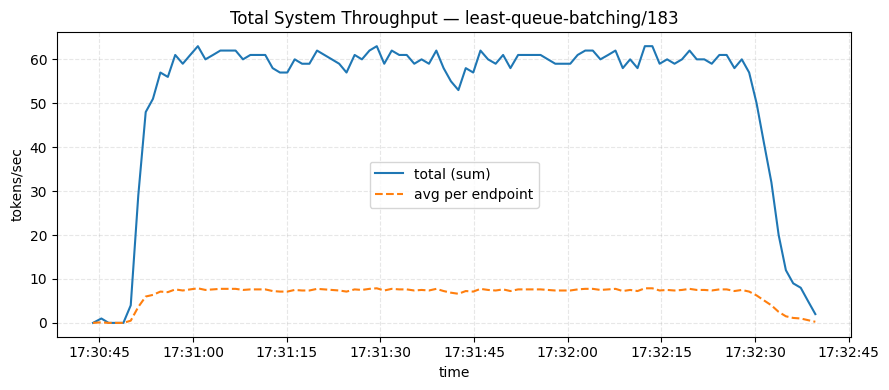

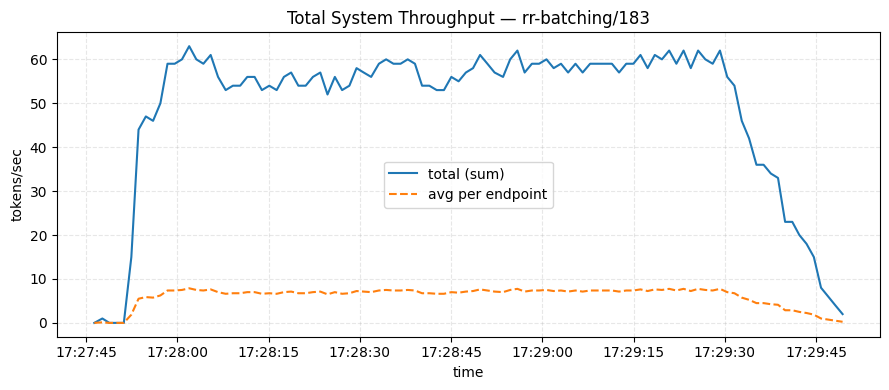

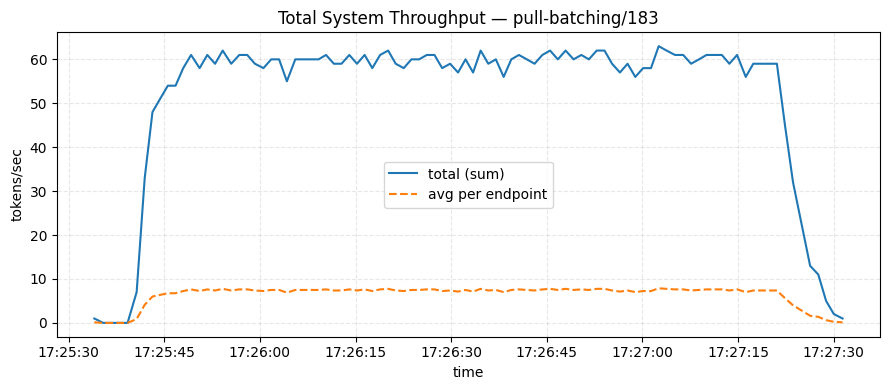

In [5]:
# quick inline plot of total throughput vs time
import matplotlib.pyplot as plt

for method, run_id in EXPERIMENTS:
    df = WIDES.get((method, run_id, "requests_running"))
    if df is None or df.empty:
        continue

    plt.figure(figsize=(9,4))
    plt.plot(df.index, df["sum_all_endpoints"], label="total (sum)")
    plt.plot(df.index, df["avg_all_endpoints"], label="avg per endpoint", linestyle="--")
    plt.title(f"Total System Throughput — {method}/{run_id}")
    plt.xlabel("time")
    plt.ylabel("tokens/sec")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


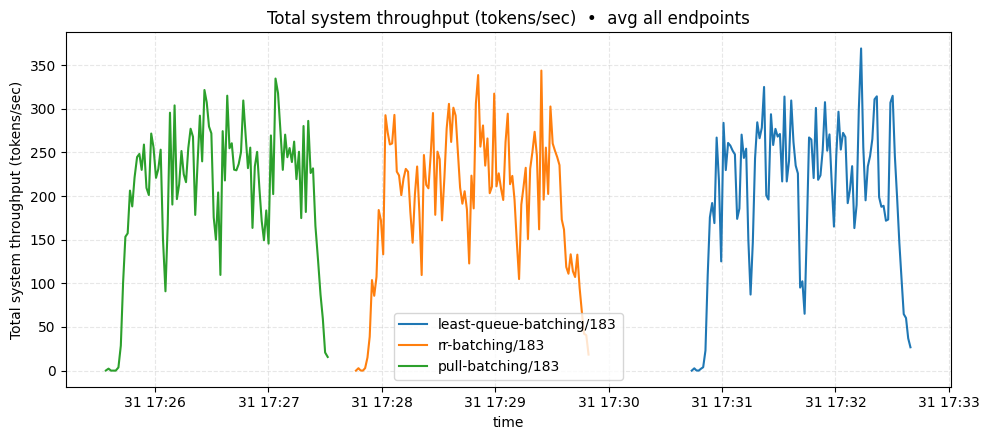

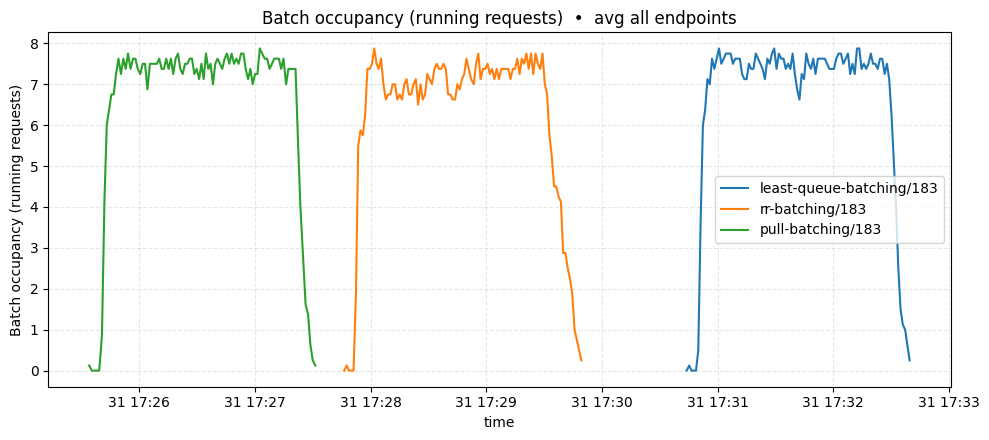

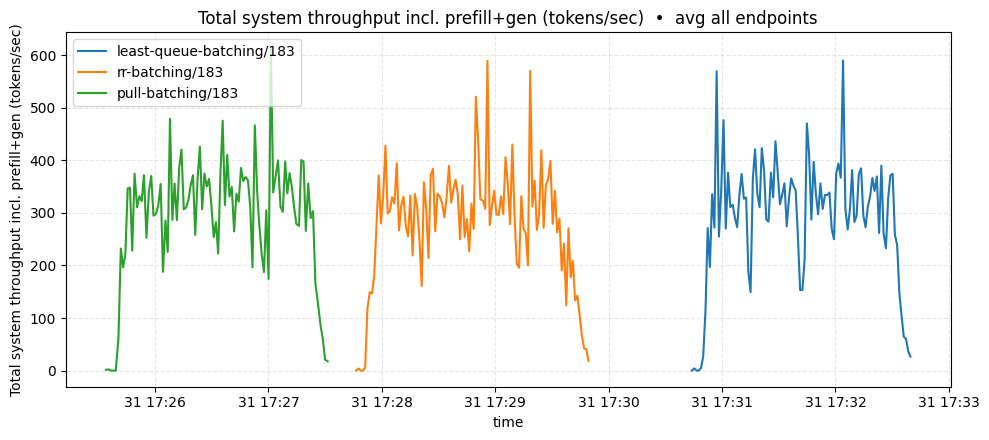

In [6]:
# Cell 5 — Compare methods (self-contained): load, wide, plot one metric per figure
import os, json
import pandas as pd
import matplotlib.pyplot as plt

# ---- Config (edit these) ----
BASE_DIR = "/home/saeid/llm-lb/results"
SERIES = "183"  # the experiment id you said to use
EXPERIMENTS = [
    ("least-queue-batching", SERIES),
    ("rr-batching", SERIES),
    ("pull-batching", SERIES),
]

# Which metrics to compare across methods (one figure per metric)
COMPARE_METRICS = [
    ("gen_tokens_per_sec", "Total system throughput (tokens/sec)"),
    ("requests_running", "Batch occupancy (running requests)"),
    ("total_tokens_per_sec", "Total system throughput incl. prefill+gen (tokens/sec)"),
]

# Aggregate column to plot from each wide table: "sum_all_endpoints" or "avg_all_endpoints"
AGG_COL = "avg_all_endpoints"

# Optional smoothing window (number of samples). Set to 0 to disable.
SMOOTH_N = 0  # e.g., 5 for light rolling mean


# ---- Minimal loaders (inline) ----
def _read_jsonl(path: str) -> pd.DataFrame:
    with open(path, "r", encoding="utf-8") as f:
        return pd.DataFrame([json.loads(line) for line in f])

def _read_queue(path: str) -> pd.DataFrame:
    with open(path, "r", encoding="utf-8") as f:
        text = f.read().strip()
    try:
        return pd.DataFrame([json.loads(line) for line in text.splitlines()])
    except Exception:
        obj = json.loads(text)
        if isinstance(obj, list):
            return pd.DataFrame(obj)
        return pd.DataFrame([obj])

def _read_results(path: str) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def load_experiment(method: str, run_id: str, base_dir: str = BASE_DIR) -> dict:
    run_path = os.path.join(base_dir, method, str(run_id))
    exp = {}
    mp = os.path.join(run_path, "metrics.jsonl")
    if os.path.exists(mp): exp["metrics"] = _read_jsonl(mp)
    op = os.path.join(run_path, "output.jsonl")
    if os.path.exists(op): exp["output"] = _read_jsonl(op)
    qp = os.path.join(run_path, "queue.json")
    if os.path.exists(qp): exp["queue"] = _read_queue(qp)
    rp = os.path.join(run_path, "results.json")
    if os.path.exists(rp): exp["results"] = _read_results(rp)
    for k in ("metrics","output","queue"):
        df = exp.get(k)
        if isinstance(df, pd.DataFrame) and "ts" in df.columns:
            df = df.copy()
            df["ts"] = pd.to_datetime(df["ts"], errors="coerce")
            exp[k] = df.sort_values("ts").reset_index(drop=True)
    return exp


# ---- Wide maker straight from raw metrics.jsonl ----
def make_wide_from_metrics_raw(metrics_df: pd.DataFrame, metric_key: str) -> pd.DataFrame:
    """
    index: ts; columns: endpoint instances; values: chosen metric
    Also appends: sum_all_endpoints, avg_all_endpoints.
    Special case: metric_key == "total_tokens_per_sec" -> gen + prefill.
    """
    if metrics_df is None or metrics_df.empty:
        return pd.DataFrame()

    rows = []
    for _, r in metrics_df.iterrows():
        ts = pd.to_datetime(r.get("ts"), errors="coerce")
        samples = r.get("samples") or []
        if isinstance(samples, dict): samples = [samples]
        out = {"ts": ts}
        for s in samples:
            if not isinstance(s, dict): continue
            inst = s.get("instance")
            if not inst: continue
            if metric_key == "total_tokens_per_sec":
                gen = s.get("gen_tokens_per_sec")
                pre = s.get("prefill_tokens_per_sec")
                val = (gen or 0.0) + (pre or 0.0) if (gen is not None or pre is not None) else None
            else:
                val = s.get(metric_key)
            out[inst] = val
        rows.append(out)

    if not rows:
        return pd.DataFrame()

    wide = pd.DataFrame.from_records(rows)
    if "ts" not in wide.columns:
        return pd.DataFrame()

    wide["ts"] = pd.to_datetime(wide["ts"], errors="coerce")
    wide = wide.sort_values("ts").set_index("ts")

    ep_cols = [c for c in wide.columns if c not in ("sum_all_endpoints","avg_all_endpoints")]
    wide["sum_all_endpoints"] = wide[ep_cols].fillna(0).sum(axis=1)
    wide["avg_all_endpoints"] = wide[ep_cols].mean(axis=1, skipna=True)
    return wide


def _get_series_for(method, run_id, metric_key, agg_col):
    exp = load_experiment(method, run_id, base_dir=BASE_DIR)
    mdf = exp.get("metrics", pd.DataFrame())
    if mdf.empty: return None
    wide = make_wide_from_metrics_raw(mdf, metric_key)
    if wide.empty or agg_col not in wide.columns: return None
    s = wide[agg_col].copy()
    s.index = pd.to_datetime(s.index, errors="coerce")
    s = s.sort_index()
    if SMOOTH_N and SMOOTH_N > 1:
        s = s.rolling(SMOOTH_N, min_periods=1).mean()
    return s


def plot_compare_methods_for_metric(metric_key, title):
    plt.figure(figsize=(10, 4.5))
    any_plotted = False
    for method, run_id in EXPERIMENTS:
        s = _get_series_for(method, run_id, metric_key, AGG_COL)
        if s is None or s.empty: continue
        plt.plot(s.index, s.values, label=f"{method}/{run_id}")
        any_plotted = True
    plt.title(f"{title}  •  {AGG_COL.replace('_', ' ')}")
    plt.xlabel("time")
    plt.ylabel(title)
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.legend(loc="best")
    plt.tight_layout()
    if not any_plotted:
        plt.close()
        print(f"[skip] No data for '{metric_key}' ({AGG_COL}).")


# ---- Make the figures: one per metric ----
for metric_key, nice_title in COMPARE_METRICS:
    plot_compare_methods_for_metric(metric_key, nice_title)


In [7]:
# Cell 6 — Experiment-level throughput summaries (averaged + integrated)
import numpy as np
import pandas as pd
from IPython.display import display

def _summarize_series(s: pd.Series) -> dict:
    """Compute descriptive stats + time-integrated total (AUC) for one time series."""
    s = s.dropna()
    if s.empty:
        return {"mean": np.nan, "p95": np.nan, "max": np.nan,
                "duration_s": 0.0, "total_integrated": 0.0, "avg_rate": np.nan}

    s = s.copy()
    s.index = pd.to_datetime(s.index, errors="coerce")
    s = s.sort_index()

    vals = s.values.astype("float64")
    t = (s.index - s.index.min()).total_seconds().astype("float64")

    if len(t) < 2:
        return {"mean": float(np.nanmean(vals)), "p95": np.nan, "max": float(np.nanmax(vals)),
                "duration_s": 0.0, "total_integrated": 0.0, "avg_rate": np.nan}

    auc = float(np.trapz(y=vals, x=t))  # value * seconds
    dur = float(t[-1] - t[0])
    return {
        "mean": float(np.nanmean(vals)),
        "p95": float(np.nanpercentile(vals, 95)),
        "max": float(np.nanmax(vals)),
        "duration_s": dur,
        "total_integrated": auc,
        "avg_rate": auc / dur if dur > 0 else np.nan,
    }


def summarize_experiments_mean(EXPERIMENTS, metrics_to_compare, agg_col="sum_all_endpoints"):
    """
    Builds an experiment-level summary (per method, per metric):
    - mean, p95, max
    - time-integrated total (AUC)
    - average rate (= AUC / duration)
    """
    rows = []
    for metric_key, nice_title in metrics_to_compare:
        for method, run_id in EXPERIMENTS:
            exp = load_experiment(method, run_id, base_dir=BASE_DIR)
            mdf = exp.get("metrics", pd.DataFrame())
            if mdf.empty:
                continue
            wide = make_wide_from_metrics_raw(mdf, metric_key)
            if wide.empty or agg_col not in wide.columns:
                continue
            s = wide[agg_col]
            stats = _summarize_series(s)
            rows.append({
                "method": method,
                "run_id": run_id,
                "metric": metric_key,
                "label": nice_title,
                **stats,
            })

    df = pd.DataFrame(rows)
    df = df.sort_values(["metric", "method", "run_id"]).reset_index(drop=True)
    return df


# === Run it ===
EXPT_SUMMARY = summarize_experiments_mean(EXPERIMENTS, COMPARE_METRICS, agg_col=AGG_COL)

# === Pretty print ===
for metric_key, nice_title in COMPARE_METRICS:
    sub = EXPT_SUMMARY[EXPT_SUMMARY["metric"] == metric_key]
    if sub.empty:
        continue
    print(f"\n### {nice_title}")
    display(
        sub[[
            "method", "run_id", "mean", "p95", "max",
            "duration_s", "total_integrated", "avg_rate"
        ]]
        .style.format({
            "mean": "{:,.2f}",
            "p95": "{:,.2f}",
            "max": "{:,.2f}",
            "duration_s": "{:,.1f}",
            "total_integrated": "{:,.0f}",
            "avg_rate": "{:,.2f}",
        })
    )


/tmp/ipykernel_2253028/419707112.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = float(np.trapz(y=vals, x=t))  # value * seconds
/tmp/ipykernel_2253028/419707112.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = float(np.trapz(y=vals, x=t))  # value * seconds
/tmp/ipykernel_2253028/419707112.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = float(np.trapz(y=vals, x=t))  # value * seconds
/tmp/ipykernel_2253028/419707112.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = float(np.trapz(y=vals, x=t))  # value * seconds
/tmp/ipykernel_2253028/419707112.py:24: DeprecationWarning: `trapz` is d


### Total system throughput (tokens/sec)


,method,run_id,mean,p95,max,duration_s,total_integrated,avg_rate
0,least-queue-batching,183,205.47,311.34,369.12,115.7,"24,003",207.49
1,pull-batching,183,204.45,307.91,334.62,117.3,"24,097",205.34
2,rr-batching,183,193.75,302.42,343.75,123.0,"24,061",195.55



### Batch occupancy (running requests)


,method,run_id,mean,p95,max,duration_s,total_integrated,avg_rate
3,least-queue-batching,183,6.51,7.75,7.88,115.7,761,6.58
4,pull-batching,183,6.48,7.75,7.88,117.3,763,6.50
5,rr-batching,183,6.13,7.73,7.88,123.0,761,6.19



### Total system throughput incl. prefill+gen (tokens/sec)


,method,run_id,mean,p95,max,duration_s,total_integrated,avg_rate
6,least-queue-batching,183,289.22,425.20,590.00,115.7,"33,792",292.11
7,pull-batching,183,291.15,421.81,612.82,117.3,"34,279",292.11
8,rr-batching,183,275.49,426.47,589.12,123.0,"34,201",277.97
